In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import pmdarima as pm
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle
from tensorflow.keras.models import load_model
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import RidgeCV, ElasticNetCV

import warnings
warnings.filterwarnings("ignore")

In [3]:
ROOT_DIR = Path.cwd().resolve().parent
DATA_DIR = ROOT_DIR / "data"
MODELS_DIR = ROOT_DIR / "models"
PREDICTIONS_DIR = ROOT_DIR / "predictions"

df = pd.read_excel(DATA_DIR / 'data1_logs_daily.xlsx', index_col=0)

In [4]:
# 1. Календарные признаки
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['weekday'] = df.index.weekday
df['day_of_year'] = df.index.dayofyear
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

df['campaign_days_elapsed'] = df.groupby('year').cumcount() + 1
df['campaign_days_remained'] = df.groupby('year')['campaign_days_elapsed'].transform('max') - df['campaign_days_elapsed']
df['campaign_week'] = df['campaign_days_elapsed'] // 7 + 1

# 2. Цикличные признаки
df['sin_weekday'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['cos_weekday'] = np.cos(2 * np.pi * df['weekday'] / 7)

# Далее будем преобразовывать только train для предотвращения утечки данных
df = df.reset_index()
train = df[df['year'] < 2024]
test = df[df['year'] == 2024]

# 3. Лаговые признаки
lags = range(1, 8)
for lag in lags:
    train[f'y_lag_{lag}'] = train['y'].shift(lag)

# 4. Скользящие средние
windows = range(1, 8)
for window in windows:
    train[f'ma_{window}'] = train['y'].shift(1).rolling(window=window).mean()

train = train.dropna().reset_index(drop=True)

X_train = train.drop(columns=['y', 'date'])
X_test = test.drop(columns=['y', 'date'])
y_train = train['y'].values
y_test = test['y'].values

In [5]:
def ensemble_predict(sarima_model, xgb_model, X_test_tpl, y_true,
                      init_window, lags=lags, windows=windows, mode='recursive'):
    preds, cur_window = [], list(init_window)
    for i, row in X_test_tpl.reset_index(drop=True).iterrows():
        sarima_fc = sarima_model.predict(n_periods=1)[0]

        feats = row.to_dict()
        for l in lags:
            feats[f'y_lag_{l}'] = cur_window[-l]
        for w in windows:
            feats[f'ma_{w}'] = np.mean(cur_window[-w:]) if len(cur_window) >= w else np.mean(cur_window)
        X_feat = pd.DataFrame([feats])[X_train.columns]

        resid_hat = xgb_model.predict(X_feat)[0]
        y_hat = sarima_fc + resid_hat

        preds.append(y_hat)

        new_obs = y_true[i] if mode == 'iterative' else y_hat
        sarima_model.update(new_obs)
        cur_window.pop(0)
        cur_window.append(new_obs)
    return np.array(preds)

def predict(model_kind, model, X_test, y_test, init_win, lags=lags, windows=windows, mode="recursive"):
    out, cw = [], list(init_win)
    for idx, row in X_test.reset_index(drop=True).iterrows():
        if model_kind == "sarima": # SARIMA
            pred = model.predict(n_periods=1)[0]
        else:
            new_features = {
                'year': row['year'],
                'month': row['month'],
                'day': row['day'],
                'weekday': row['weekday'],
                'day_of_year': row['day_of_year'],
                'is_weekend': row['is_weekend'],
                'campaign_days_elapsed': row['campaign_days_elapsed'],
                'campaign_days_remained': row['campaign_days_remained'],
                'sin_weekday': row['sin_weekday'],
                'cos_weekday': row['cos_weekday']
            }

            for lag in lags:
                new_features[f'y_lag_{lag}'] = cw[-lag]

            if model_kind == "xgb": # XGB
                new_features['ma_3'] = np.mean(cw[-3:]) if len(cw) >= 3 else np.mean(cw)
                new_features['ma_7'] = np.mean(cw[-7:]) if len(cw) >= 7 else np.mean(cw)
                input_df = pd.DataFrame([new_features])
                pred = model.named_steps['regressor'].predict(model.named_steps['feature_selection'].transform(input_df))[0]
            else: # LSTM
                new_features['campaign_week'] = new_features['campaign_days_elapsed'] // 7 + 1
                for window in windows:
                    new_features[f'ma_{window}'] = np.mean(cw[-window:]) if len(cw) >= window else np.mean(cw)
                
                input_df = pd.DataFrame([new_features])
                
                lag_columns = [col for col in X_train.columns if col.startswith('y_lag_')]
                static_columns = [col for col in X_train.columns if col not in lag_columns]

                seq_input_arr = input_df[lag_columns].values.reshape(1, len(lag_columns), 1)
                static_input_arr = input_df[static_columns].values
                
                pred = model.predict([seq_input_arr, static_input_arr], verbose=0)[0, 0]

        cw.pop(0)
        if mode == "iterative":
            cw.append(y_test[idx])
        else:
            cw.append(pred)
        out.append(pred)

    return np.array(out)   

def plot(y_pred, y_test, title='', interval=7, figsize=(12, 6), dates=df[df['year'] == 2024]['date']):
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(dates, y_test, label='Фактические данные')
    ax.plot(dates, y_pred, label='Прогноз', color='red')
    
    ax.set_xlabel('Дата')
    ax.set_ylabel('Количество заявок')
    ax.set_title(title)

    locator = mdates.DayLocator(interval=interval)
    ax.xaxis.set_major_locator(locator)

    ax.legend()
    ax.grid()
    plt.show()

def metrics(name, y, yhat):
    rmse = np.sqrt(mean_squared_error(y, yhat))
    mae  = mean_absolute_error(y, yhat)
    print(f"{name:<10s}: RMSE {rmse:.3f} | MAE {mae:.3f}")

### 1. SARIMA + XGBoost на остатках

In [72]:
sarima = pm.auto_arima(
    y_train, seasonal=True, m=7,
    d=1, D=1, max_p=3, max_q=3, max_P=2, max_Q=2,
    suppress_warnings=True, stepwise=True
).fit(y_train)

In [73]:
sarima_fitted = sarima.predict_in_sample()
sarima_residuals = y_train - sarima_fitted

In [12]:
param_grid = {
    'n_estimators': [50, 100, 300, 500],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

gs = GridSearchCV(XGBRegressor(random_state=42), param_grid=param_grid, scoring='neg_root_mean_squared_error', n_jobs=-1)
gs.fit(X_train, sarima_residuals)

GridSearchCV(estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bi...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 300, 500],
                         'subsample': [0.8, 1.0]},
             scoring='neg_root_mean_squared_error')

In [13]:
print(f"Best params: {gs.best_params_}")
xgb = gs.best_estimator_

Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300, 'subsample': 0.8}


In [14]:
init_window = y_train[-7:]

y_pred_rec  = ensemble_predict(sarima, xgb, X_test, y_test, init_window, mode='recursive')
y_pred_iter = ensemble_predict(sarima, xgb, X_test, y_test, init_window, mode='iterative')

In [15]:
metrics("Ens‑rec",  y_test, y_pred_rec)
metrics("Ens‑iter", y_test, y_pred_iter)

Ens‑rec   : RMSE 111.241 | MAE 84.553
Ens‑iter  : RMSE 82.943 | MAE 70.186


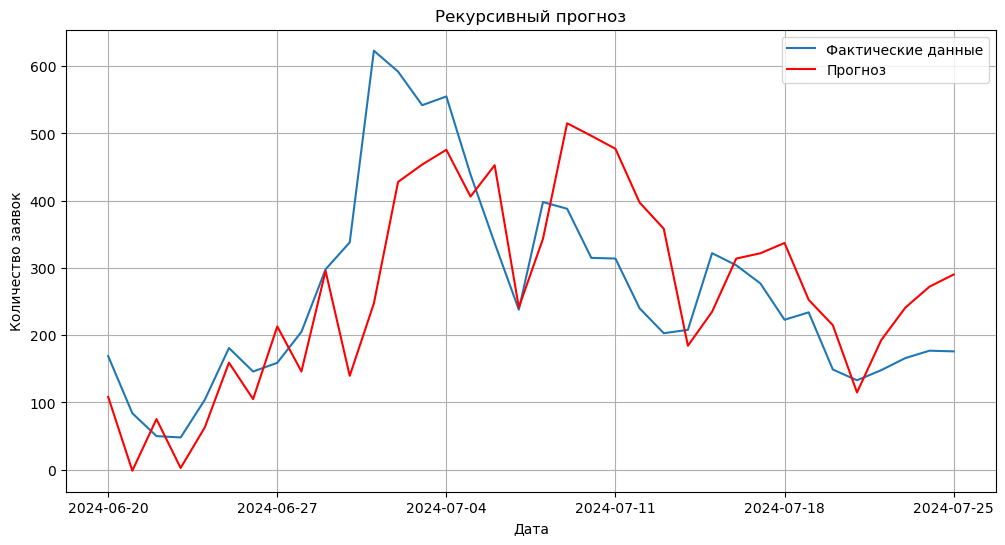

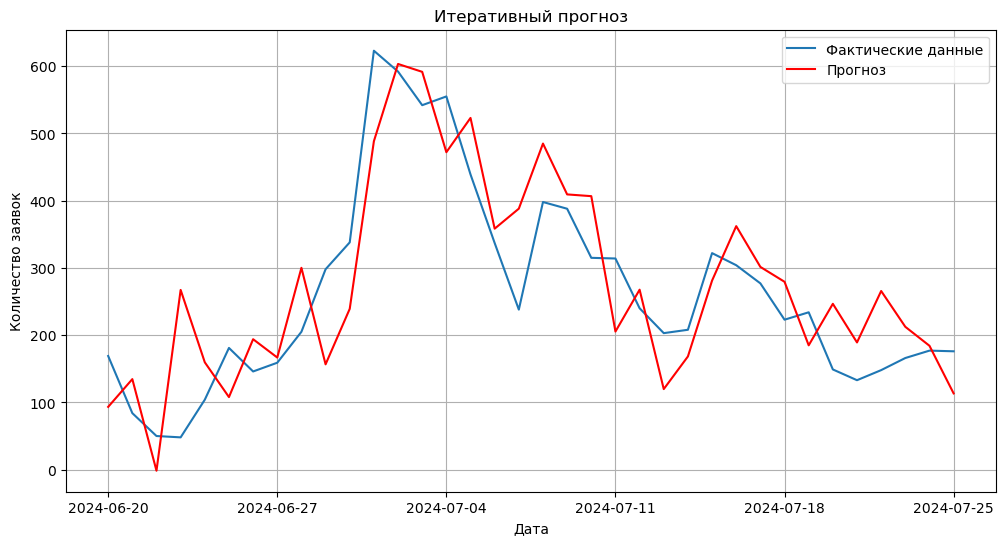

In [16]:
plot(y_pred_rec, y_test, title="Рекурсивный прогноз")
plot(y_pred_iter, y_test, title="Итеративный прогноз")

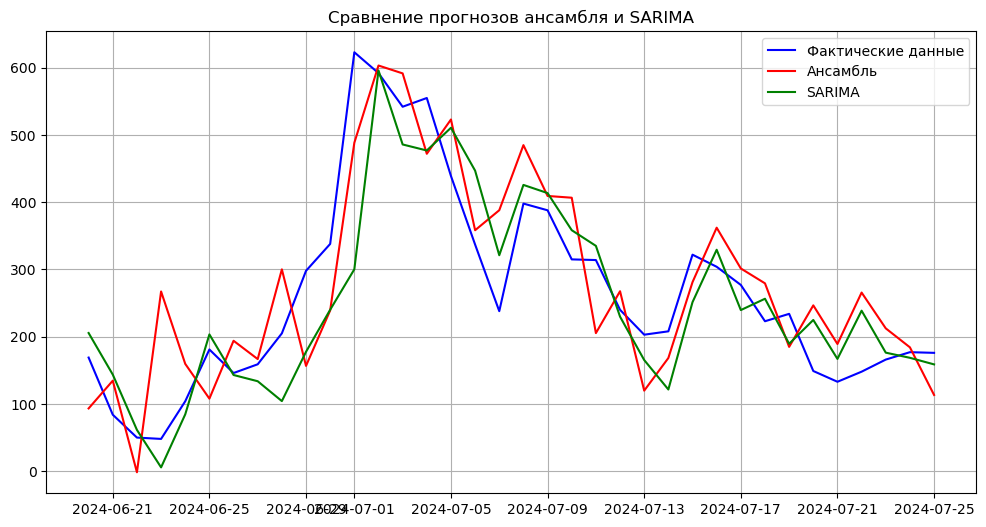

In [17]:
import json

with open(ROOT_DIR / "predictions/arima_daily_predictions.json", "r") as file:
    arima_daily_predictions = json.load(file)

plt.figure(figsize=(12, 6))
plt.plot(df[df['year'] == 2024]['date'], y_test, color='blue', label="Фактические данные")
plt.plot(df[df['year'] == 2024]['date'], y_pred_iter, color='red', label="Ансамбль")
plt.plot(df[df['year'] == 2024]['date'], arima_daily_predictions, color='green', label="SARIMA")
plt.title("Сравнение прогнозов ансамбля и SARIMA")
plt.legend()
plt.grid()
plt.show()

In [18]:
metrics("Ансамбль", y_test, y_pred_iter)
metrics("SARIMA", y_test, arima_daily_predictions)

Ансамбль  : RMSE 82.943 | MAE 70.186
SARIMA    : RMSE 77.931 | MAE 54.574


### 2. Meta-learner

In [19]:
# SARIMA
sarima = pm.auto_arima(
    y_train, seasonal=True, m=7,
    d=1, D=1, max_p=3, max_q=3, max_P=2, max_Q=2,
    suppress_warnings=True, stepwise=True
).fit(y_train)

In [20]:
# XGBoost
with open(MODELS_DIR / "xgb_daily_model.pkl", "rb") as file:
    xgb = pickle.load(file)

In [ ]:
# LSTM
lstm = load_model(MODELS_DIR / "lstm_daily_model.keras")

In [84]:
init_window = y_train[-7:]

# 2023
X_val = X_train[-36:]
y_val = y_train[-36:]

sar_val  = predict('sarima', sarima, X_val, y_val, init_window, mode="iterative")
xgb_val  = predict('xgb', xgb, X_val, y_val, init_window, mode="iterative")
lstm_val = predict('lstm', lstm, X_val, y_val, init_window, mode="iterative")

sar_test  = predict('sarima', sarima, X_test, y_test, init_window, mode="iterative")
xgb_test  = predict('xgb', xgb, X_test, y_test, init_window, mode="iterative")
lstm_test = predict('lstm', lstm, X_test, y_test, init_window, mode="iterative")

#### 2.1 Ridge

In [85]:
cv = TimeSeriesSplit()

meta_ridge = RidgeCV(cv=cv)
meta_ridge.fit(np.vstack([sar_val, xgb_val, lstm_val]).T, y_val)

y_pred_meta_ridge = meta_ridge.predict(np.vstack([sar_test, xgb_test, lstm_test]).T)
print(f"Weight: {dict(zip(['SARIMA', 'XGB', 'LSTM'], meta_ridge.coef_.round(3)))}")

Weight: {'SARIMA': 0.0, 'XGB': 1.066, 'LSTM': -0.114}


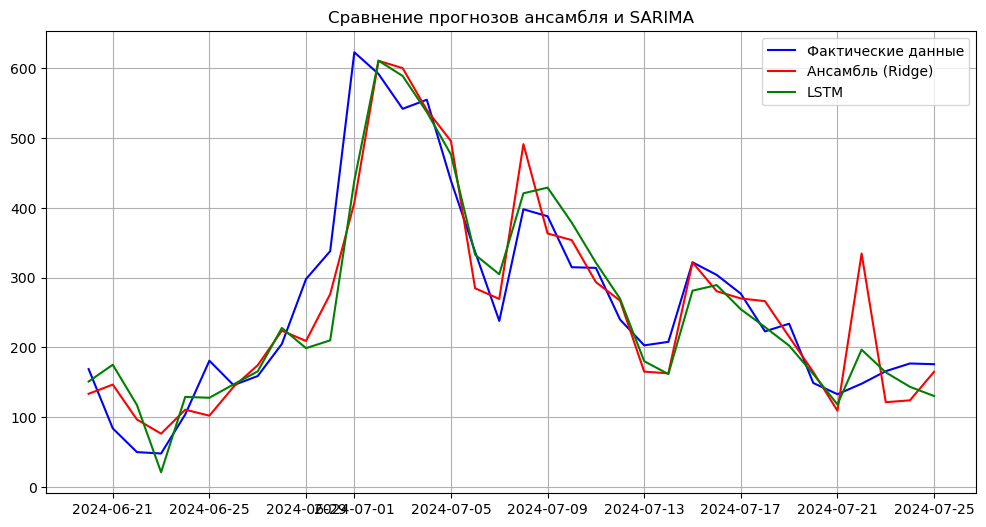

In [86]:
with open(ROOT_DIR / "predictions/lstm_daily_predictions.json", "r") as file:
    lstm_daily_predictions = json.load(file)

plt.figure(figsize=(12, 6))
plt.plot(df[df['year'] == 2024]['date'], y_test, color='blue', label="Фактические данные")
plt.plot(df[df['year'] == 2024]['date'], y_pred_meta_ridge, color='red', label="Ансамбль (Ridge)")
plt.plot(df[df['year'] == 2024]['date'], lstm_daily_predictions, color='green', label="LSTM")
plt.title("Сравнение прогнозов ансамбля и SARIMA")
plt.legend()
plt.grid()
plt.show()

In [87]:
metrics("Ансамбль", y_test, y_pred_meta_ridge)
metrics("LSTM", y_test, lstm_daily_predictions)

Ансамбль  : RMSE 63.006 | MAE 44.658
LSTM      : RMSE 54.261 | MAE 39.493


#### 2.2. Elastic Net

In [88]:
meta_en = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.9, 1.0],
    cv=cv,
    fit_intercept=False,
    positive=True
).fit(np.vstack([sar_val, xgb_val, lstm_val]).T, y_val)

print(f"Weigts: {dict(zip(['SARIMA', 'XGB', 'LSTM'], meta_en.coef_.round(3)))}")
y_pred_meta_en = meta_en.predict(np.vstack([sar_test, xgb_test, lstm_test]).T)

Weigts: {'SARIMA': 0.04, 'XGB': 0.969, 'LSTM': 0.0}


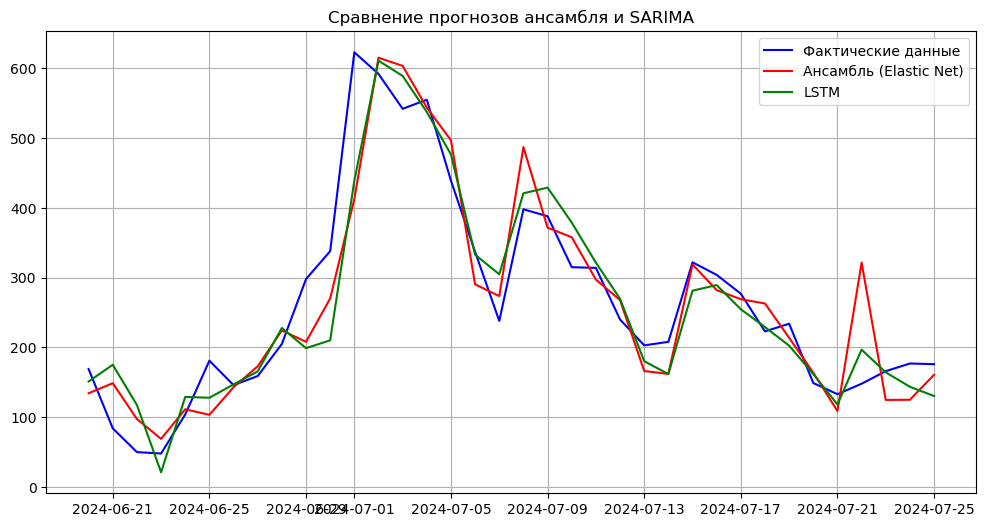

In [89]:
plt.figure(figsize=(12, 6))
plt.plot(df[df['year'] == 2024]['date'], y_test, color='blue', label="Фактические данные")
plt.plot(df[df['year'] == 2024]['date'], y_pred_meta_en, color='red', label="Ансамбль (Elastic Net)")
plt.plot(df[df['year'] == 2024]['date'], lstm_daily_predictions, color='green', label="LSTM")
plt.title("Сравнение прогнозов ансамбля и SARIMA")
plt.legend()
plt.grid()
plt.show()

In [90]:
metrics("Ансамбль", y_test, y_pred_meta_en)
metrics("LSTM", y_test, lstm_daily_predictions)

Ансамбль  : RMSE 61.377 | MAE 43.973
LSTM      : RMSE 54.261 | MAE 39.493
